# 📓 CELDA 1: Configuración inicial
"""
#### PREDICCIÓN DE PRECIOS DE VIVIENDAS - BOSTON
============================================
#### EDA (Análisis Exploratorio de Datos)
#### Autor: Tu Nombre
#### Fecha: 2026-07-02
"""

In [35]:
"""
PREDICCIÓN DE PRECIOS DE VIVIENDAS - AMES HOUSING
===================================================
EDA (Análisis Exploratorio de Datos)
Dataset: Ames Housing (79 features originales)
Autor: Tu Nombre
Fecha: 2026-07-07
"""

# Importaciones
import sys
from pathlib import Path

# Añadir raíz del proyecto al path
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configurar visualización
%matplotlib inline
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Crear carpeta para guardar gráficos
from pathlib import Path
Path('../reports/figures/eda_plots').mkdir(parents=True, exist_ok=True)

print("✅ Configuración completada")
print(f"📁 Proyecto raíz: {project_root}")

✅ Configuración completada
📁 Proyecto raíz: <directorio del proyecto>


In [36]:
# Cargar datos procesados
X_train = pd.read_csv('../data/processed/X_train.csv')
y_train = pd.read_csv('../data/processed/y_train.csv')

# Combinar para EDA
df = pd.concat([X_train, y_train], axis=1)

print(f"📊 Dataset cargado:")
print(f"  - Registros: {df.shape[0]:,}")
print(f"  - Columnas: {df.shape[1]:,}")
print(f"  - Memoria: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Ver primeras filas
df.head()

📊 Dataset cargado:
  - Registros: 1,113
  - Columnas: 214
  - Memoria: 0.70 MB


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,SalePrice
0,90,60.0,-0.273969,5,5,1977,1977,320.0,3,3,...,False,False,False,True,False,False,False,True,False,144000
1,70,50.0,-2.067114,7,8,1915,2005,0.0,4,3,...,False,False,False,True,False,False,False,True,False,155000
2,160,21.0,-2.316330,6,7,1972,1972,281.0,3,3,...,False,False,False,True,False,False,False,True,False,118000
3,30,56.0,-1.571720,3,6,1935,2003,0.0,4,3,...,False,False,False,True,False,False,False,True,False,52000
4,90,68.0,-0.112890,6,5,1978,1978,0.0,3,3,...,False,False,False,True,False,False,False,True,False,112000


In [37]:
print("="*60)
print("INFORMACIÓN DEL DATASET")
print("="*60)

# Info general
df.info()

print("\n" + "="*60)
print("ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS")
print("="*60)

# Seleccionar solo columnas numéricas (evitar las categóricas one-hot)
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols].describe()

INFORMACIÓN DEL DATASET
<class 'pandas.DataFrame'>
RangeIndex: 1113 entries, 0 to 1112
Columns: 214 entries, MSSubClass to SalePrice
dtypes: bool(151), float64(28), int64(35)
memory usage: 712.1 KB

ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,...,Bsmt_Qual,TotalSF,Qual_Cond,Age_Qual,TotalPorchSF,GrLivArea_sq,OverallQual_sq,TotalBsmtSF_sq,HouseAge_sq,SalePrice
count,1113.000000,935.000000,1113.000000,1113.000000,1113.000000,1113.000000,1113.000000,1108.000000,1113.000000,1113.000000,...,1113.000000,1113.000000,1113.000000,1113.000000,1113.000000,1113.000000,1113.000000,1113.000000,1113.000000,1113.000000
mean,56.621743,68.785027,-0.005446,6.056604,5.572327,1971.402516,1984.795148,98.613718,3.394429,3.079066,...,-0.011623,-0.015874,-0.008782,0.001878,80.796945,-0.013182,-0.006605,-0.015462,0.008634,175589.035040
std,42.241041,20.970148,0.988631,1.364844,1.095456,30.447851,20.780008,170.609759,0.568860,0.343284,...,0.986287,0.994235,0.997225,1.009607,99.614744,0.993139,1.001840,0.968279,1.008835,72040.622045
min,20.000000,21.000000,-2.431821,1.000000,2.000000,1872.000000,1950.000000,0.000000,2.000000,1.000000,...,-1.809973,-3.058896,-3.434988,-1.192232,0.000000,-1.511470,-2.214331,-1.320082,-0.763639,34900.000000
25%,20.000000,60.000000,-0.563000,5.000000,5.000000,1954.000000,1966.000000,0.000000,3.000000,3.000000,...,-0.629128,-0.746801,-0.408862,-0.893793,0.000000,-0.762201,-0.803026,-0.661696,-0.746863,128000.000000
50%,50.000000,69.000000,-0.037214,6.000000,5.000000,1973.000000,1994.000000,0.000000,3.000000,3.000000,...,-0.268544,-0.103460,0.151532,-0.065474,45.000000,-0.228893,-0.156178,-0.291354,-0.367852,159000.000000
75%,70.000000,80.000000,0.577014,7.000000,6.000000,2001.000000,2004.000000,162.000000,4.000000,3.000000,...,0.492261,0.645232,0.711925,0.513132,126.000000,0.409201,0.608279,0.391283,0.272049,209500.000000
max,190.000000,182.000000,3.157319,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5.000000,5.000000,...,5.249772,3.298663,6.315863,5.811940,1027.000000,4.168196,3.607302,9.689619,5.568954,611657.000000


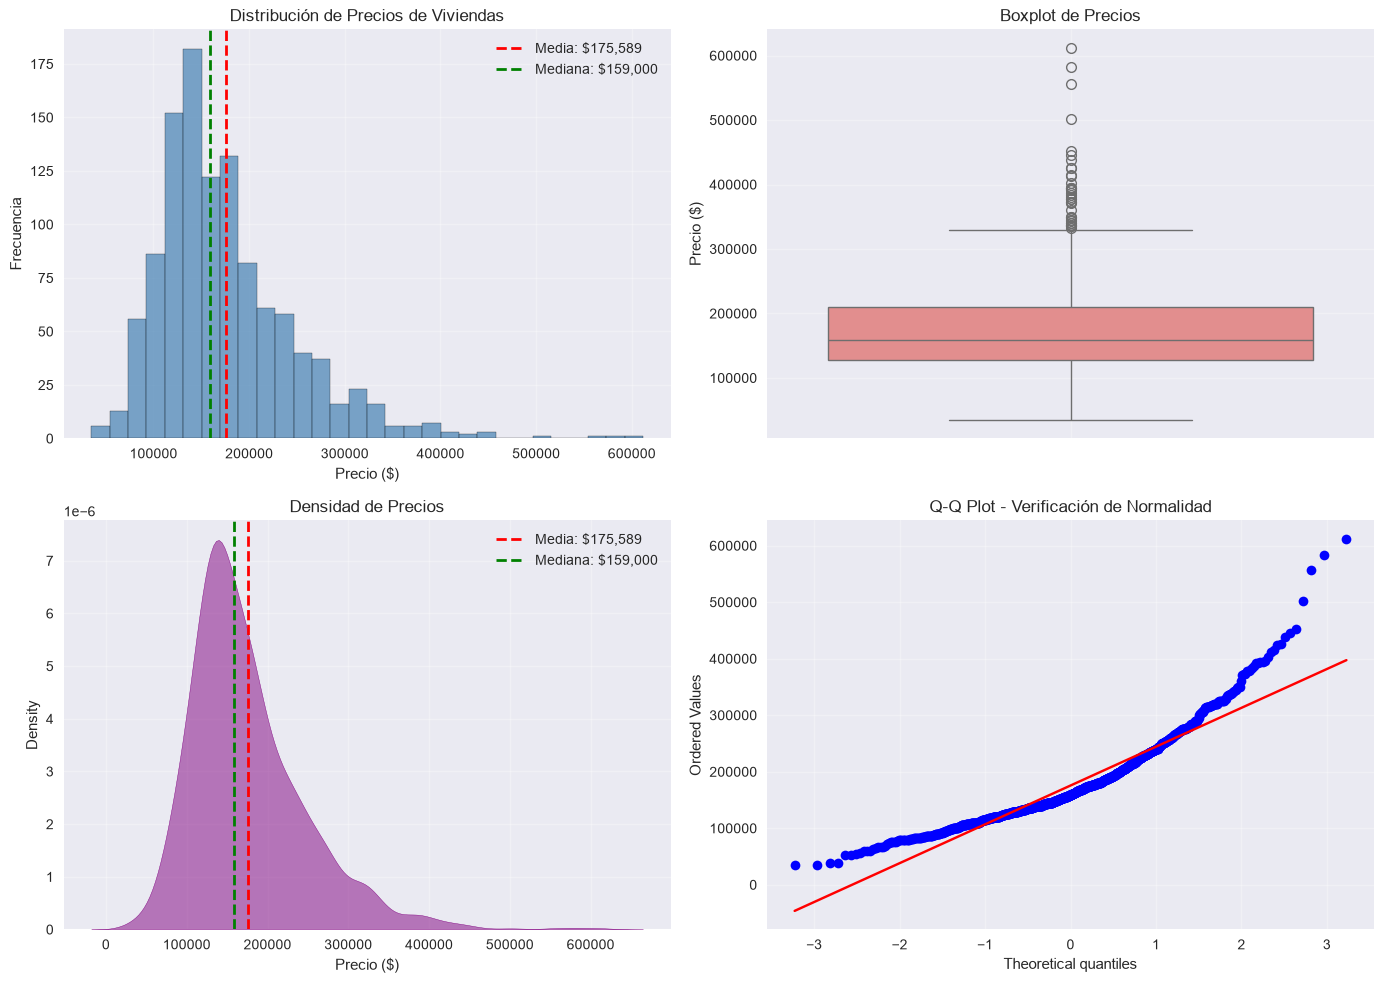


📊 ESTADÍSTICAS DE SalePrice:
  - Media: $175,589.04
  - Mediana: $159,000.00
  - Mínimo: $34,900.00
  - Máximo: $611,657.00
  - Desviación estándar: $72,040.62
  - Asimetría: 1.451
  - Curtosis: 3.650
  - IQR: $81,500.00


In [38]:
# Análisis de la variable objetivo
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histograma
ax1 = axes[0, 0]
ax1.hist(df['SalePrice'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(df['SalePrice'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: ${df["SalePrice"].mean():,.0f}')
ax1.axvline(df['SalePrice'].median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: ${df["SalePrice"].median():,.0f}')
ax1.set_title('Distribución de Precios de Viviendas')
ax1.set_xlabel('Precio ($)')
ax1.set_ylabel('Frecuencia')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Boxplot
ax2 = axes[0, 1]
sns.boxplot(y=df['SalePrice'], ax=ax2, color='lightcoral')
ax2.set_title('Boxplot de Precios')
ax2.set_ylabel('Precio ($)')
ax2.grid(True, alpha=0.3)

# 3. KDE (densidad)
ax3 = axes[1, 0]
sns.kdeplot(df['SalePrice'], ax=ax3, fill=True, color='purple', alpha=0.5)
ax3.axvline(df['SalePrice'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: ${df["SalePrice"].mean():,.0f}')
ax3.axvline(df['SalePrice'].median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: ${df["SalePrice"].median():,.0f}')
ax3.set_title('Densidad de Precios')
ax3.set_xlabel('Precio ($)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. QQ-plot para normalidad
from scipy import stats
ax4 = axes[1, 1]
stats.probplot(df['SalePrice'], dist="norm", plot=ax4)
ax4.set_title('Q-Q Plot - Verificación de Normalidad')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/eda_plots/saleprice_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Estadísticas
print("\n📊 ESTADÍSTICAS DE SalePrice:")
print(f"  - Media: ${df['SalePrice'].mean():,.2f}")
print(f"  - Mediana: ${df['SalePrice'].median():,.2f}")
print(f"  - Mínimo: ${df['SalePrice'].min():,.2f}")
print(f"  - Máximo: ${df['SalePrice'].max():,.2f}")
print(f"  - Desviación estándar: ${df['SalePrice'].std():,.2f}")
print(f"  - Asimetría: {df['SalePrice'].skew():.3f}")
print(f"  - Curtosis: {df['SalePrice'].kurtosis():.3f}")
print(f"  - IQR: ${df['SalePrice'].quantile(0.75) - df['SalePrice'].quantile(0.25):,.2f}")

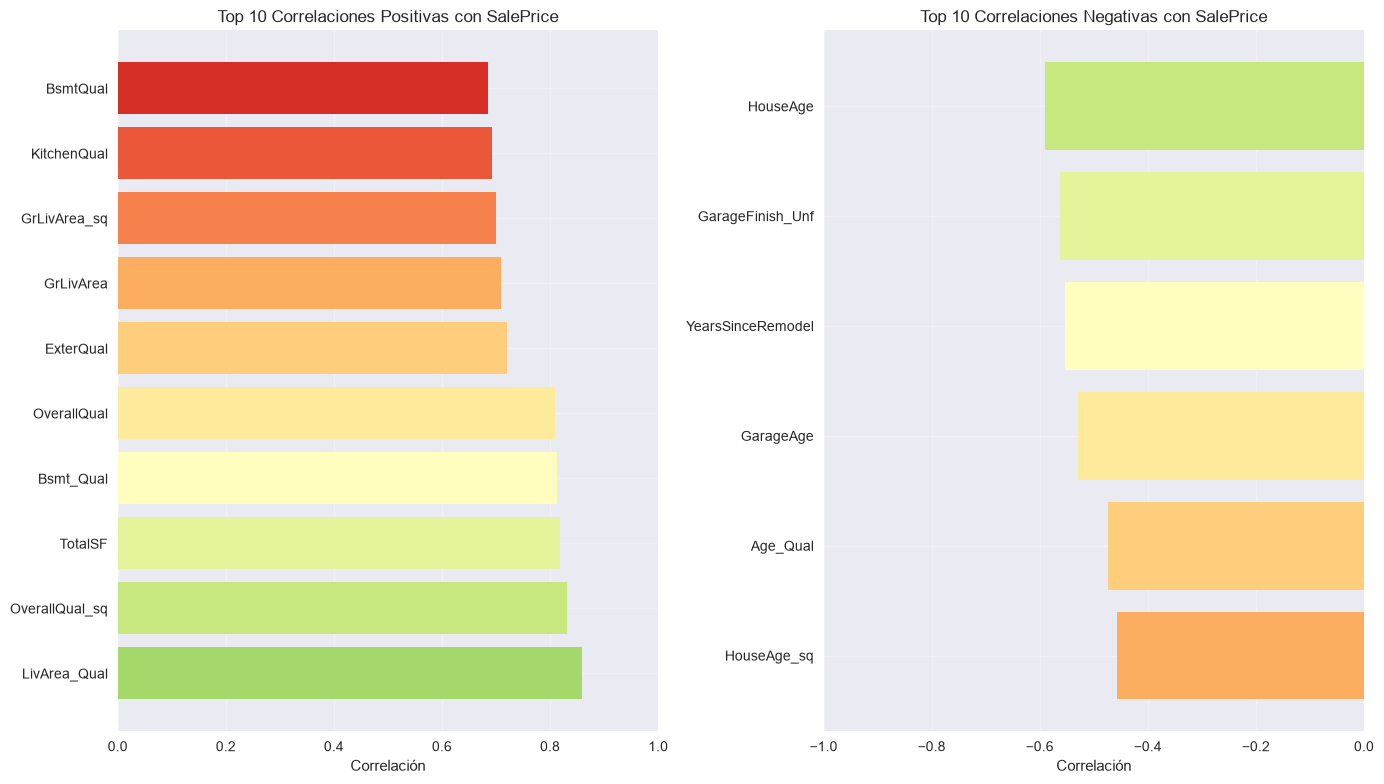


📊 TOP 10 CORRELACIONES POSITIVAS:
LivArea_Qual      0.858706
OverallQual_sq    0.831837
TotalSF           0.817752
Bsmt_Qual         0.812157
OverallQual       0.809323
ExterQual         0.720622
GrLivArea         0.708887
GrLivArea_sq      0.699502
KitchenQual       0.692724
BsmtQual          0.685123
Name: SalePrice, dtype: float64

📊 TOP 10 CORRELACIONES NEGATIVAS:
HouseAge_sq           -0.457827
Age_Qual              -0.473871
GarageAge             -0.530098
YearsSinceRemodel     -0.552677
GarageFinish_Unf      -0.561942
HouseAge              -0.590880
Condition2_PosN             NaN
RoofMatl_Roll               NaN
RoofMatl_WdShngl            NaN
Exterior1st_AsphShn         NaN
Name: SalePrice, dtype: float64


In [39]:
# Calcular correlaciones con SalePrice
correlations = df.corr()['SalePrice'].sort_values(ascending=False)

# Top 10 positivas (excluyendo SalePrice)
top_positive = correlations[1:11]

# Top 10 negativas
top_negative = correlations.tail(10)

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Positivas
ax1 = axes[0]
colors = plt.cm.RdYlGn_r(np.linspace(0.3, 0.9, len(top_positive)))
ax1.barh(top_positive.index, top_positive.values, color=colors)
ax1.set_title('Top 10 Correlaciones Positivas con SalePrice')
ax1.set_xlabel('Correlación')
ax1.set_xlim(0, 1)
ax1.grid(True, alpha=0.3)

# Negativas
ax2 = axes[1]
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top_negative)))
ax2.barh(top_negative.index, top_negative.values, color=colors)
ax2.set_title('Top 10 Correlaciones Negativas con SalePrice')
ax2.set_xlabel('Correlación')
ax2.set_xlim(-1, 0)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/eda_plots/top_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 TOP 10 CORRELACIONES POSITIVAS:")
print(top_positive)
print("\n📊 TOP 10 CORRELACIONES NEGATIVAS:")
print(top_negative)

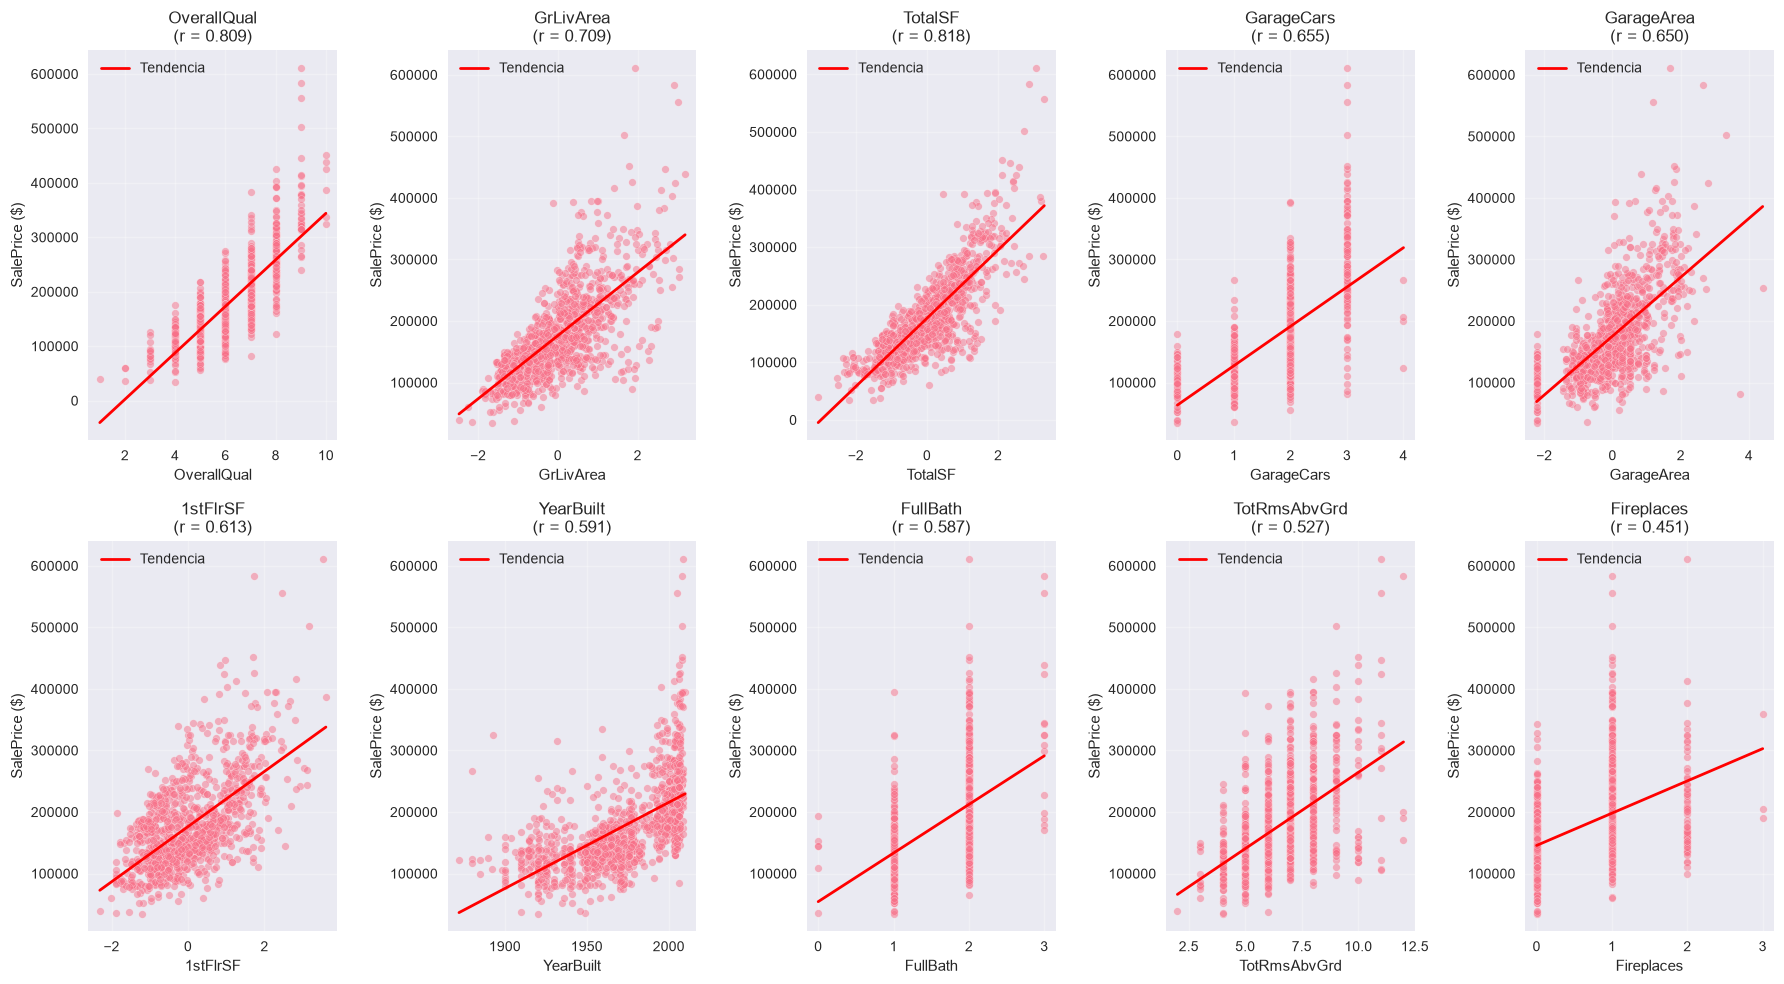

In [40]:
# Variables más importantes según correlación
top_features = ['OverallQual', 'GrLivArea', 'TotalSF', 'GarageCars', 'GarageArea', 
                '1stFlrSF', 'YearBuilt', 'FullBath', 'TotRmsAbvGrd', 'Fireplaces']

fig, axes = plt.subplots(2, 5, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    if feature in df.columns:
        ax = axes[i]
        
        # Scatter plot con línea de tendencia
        ax.scatter(df[feature], df['SalePrice'], alpha=0.5, s=30, edgecolor='white')
        
        # Línea de tendencia
        z = np.polyfit(df[feature], df['SalePrice'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(df[feature].min(), df[feature].max(), 100)
        ax.plot(x_line, p(x_line), color='red', linewidth=2, label='Tendencia')
        
        # Correlación
        corr = df[feature].corr(df['SalePrice'])
        ax.set_title(f'{feature}\n(r = {corr:.3f})')
        ax.set_xlabel(feature)
        ax.set_ylabel('SalePrice ($)')
        ax.legend()
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/eda_plots/features_vs_price.png', dpi=300, bbox_inches='tight')
plt.show()

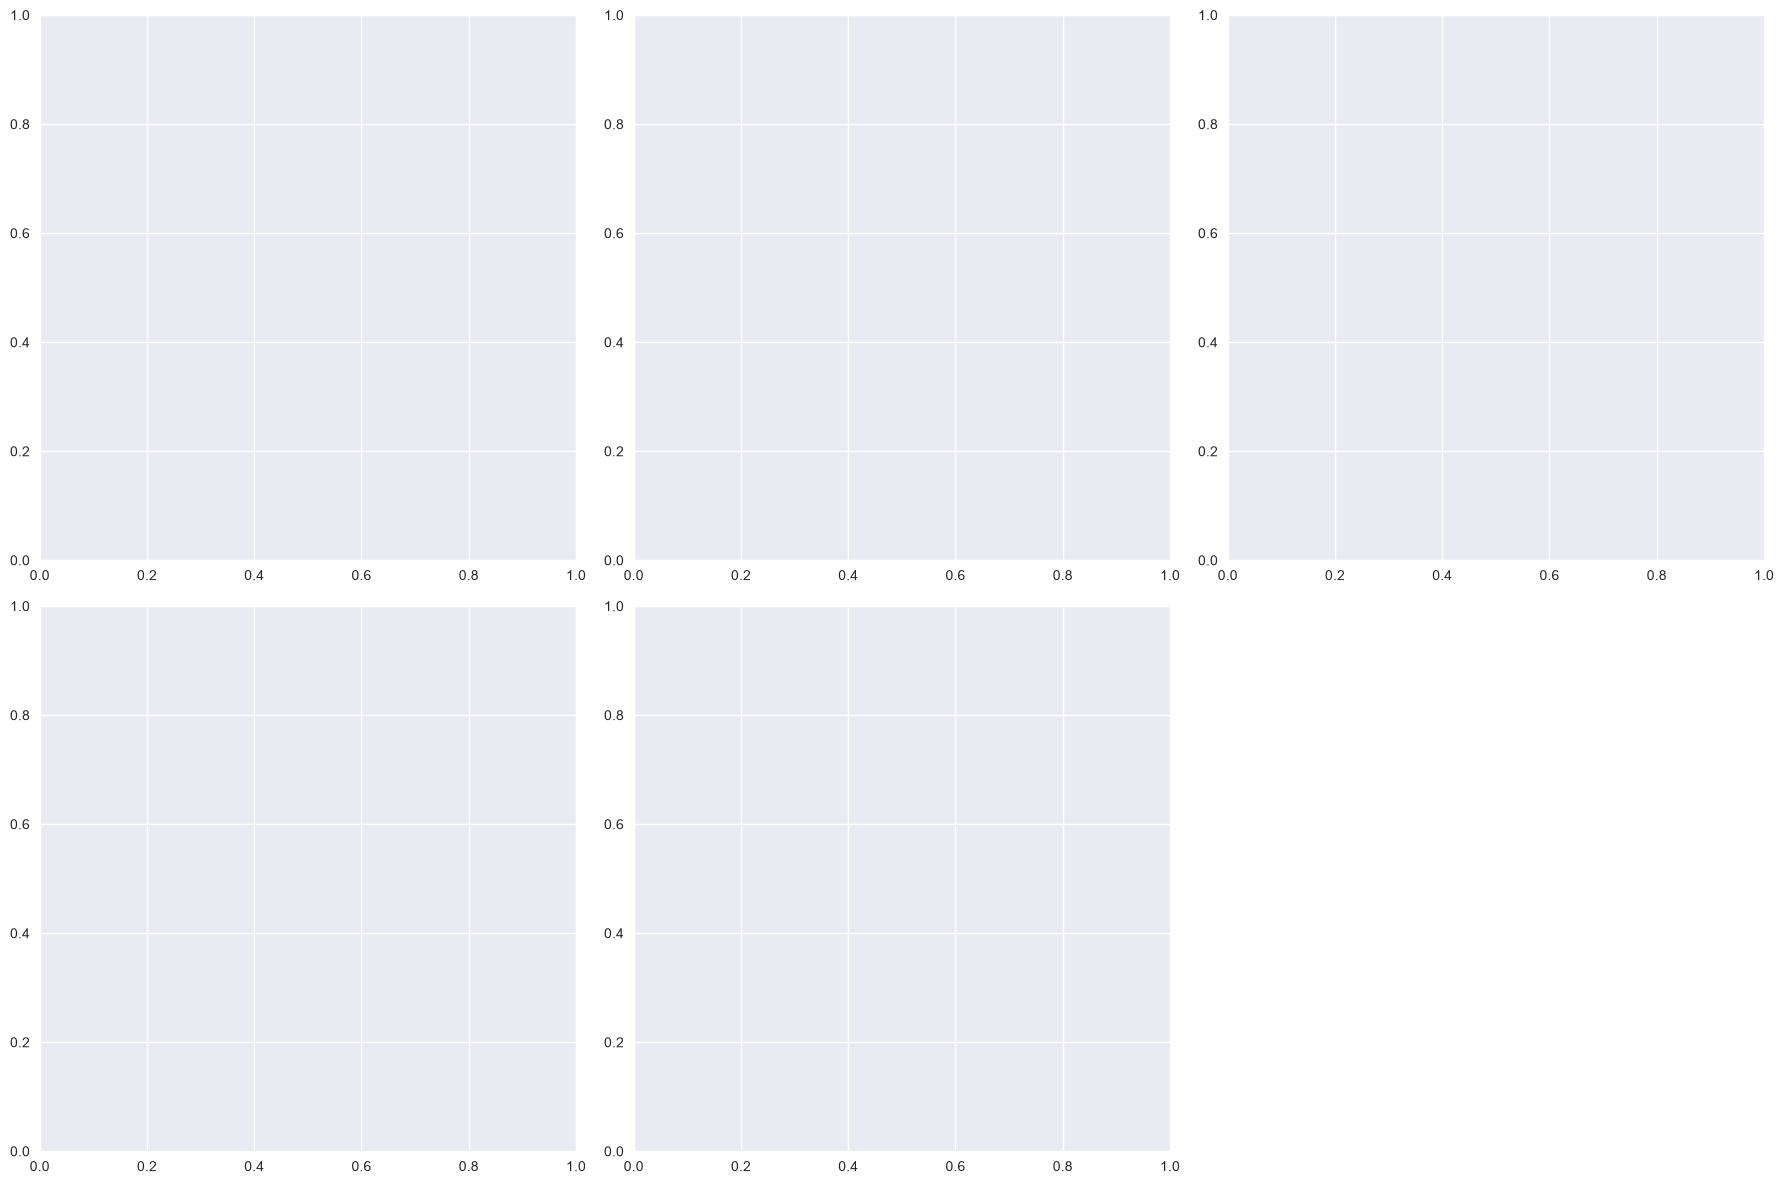

In [42]:
# Variables categóricas clave (originales, no one-hot)
categorical_features = ['Neighborhood', 'MSZoning', 'SaleType', 'CentralAir', 'BldgType']

# Crear gráficos
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, feature in enumerate(categorical_features):
    if feature in df.columns:
        ax = axes[i]
        
        # Agrupar por categoría y calcular precio medio
        grouped = df.groupby(feature)['SalePrice'].mean().sort_values(ascending=False)
        
        # Graficar
        grouped.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
        ax.set_title(f'Precio Medio por {feature}')
        ax.set_xlabel(feature)
        ax.set_ylabel('Precio Medio ($)')
        ax.tick_params(axis='x', rotation=45)
        ax.grid(True, alpha=0.3)
        
        # Añadir valores encima de barras
        for j, v in enumerate(grouped.values):
            ax.text(j, v + 1000, f'${v:,.0f}', ha='center', va='bottom', fontsize=8)

# Ocultar ejes vacíos
for i in range(len(categorical_features), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/figures/eda_plots/categorical_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

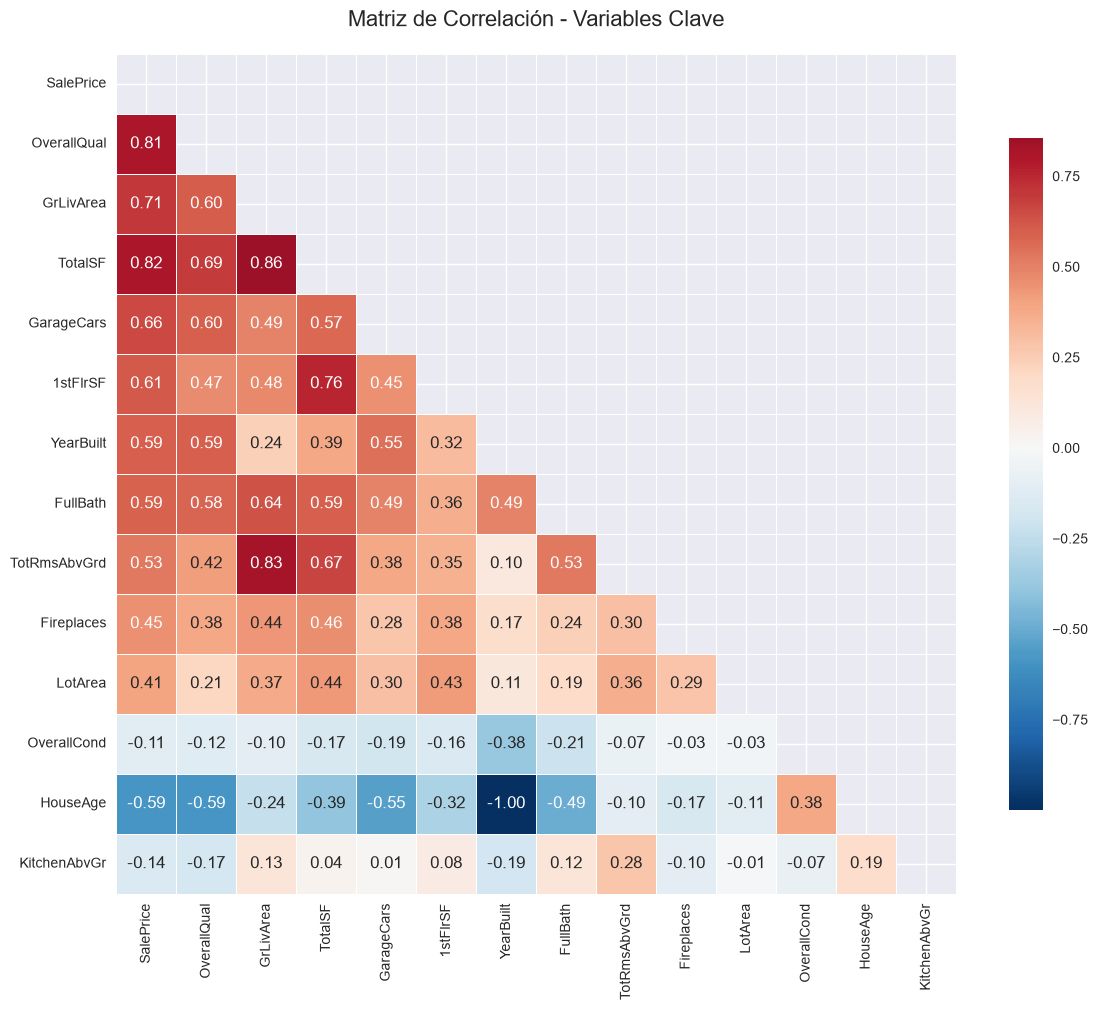

In [43]:
# Seleccionar las variables más relevantes para la matriz
top_corr_features = ['SalePrice', 'OverallQual', 'GrLivArea', 'TotalSF', 'GarageCars', 
                     '1stFlrSF', 'YearBuilt', 'FullBath', 'TotRmsAbvGrd', 'Fireplaces',
                     'LotArea', 'OverallCond', 'HouseAge', 'KitchenAbvGr']

# Filtrar columnas que existen en el dataframe
available_features = [col for col in top_corr_features if col in df.columns]

# Calcular matriz de correlación
corr_matrix = df[available_features].corr()

# Visualizar
plt.figure(figsize=(12, 10))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, 
            mask=mask,
            annot=True, 
            fmt='.2f', 
            cmap='RdBu_r',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

plt.title('Matriz de Correlación - Variables Clave', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig('../reports/figures/eda_plots/correlation_matrix_reduced.png', dpi=300, bbox_inches='tight')
plt.show()

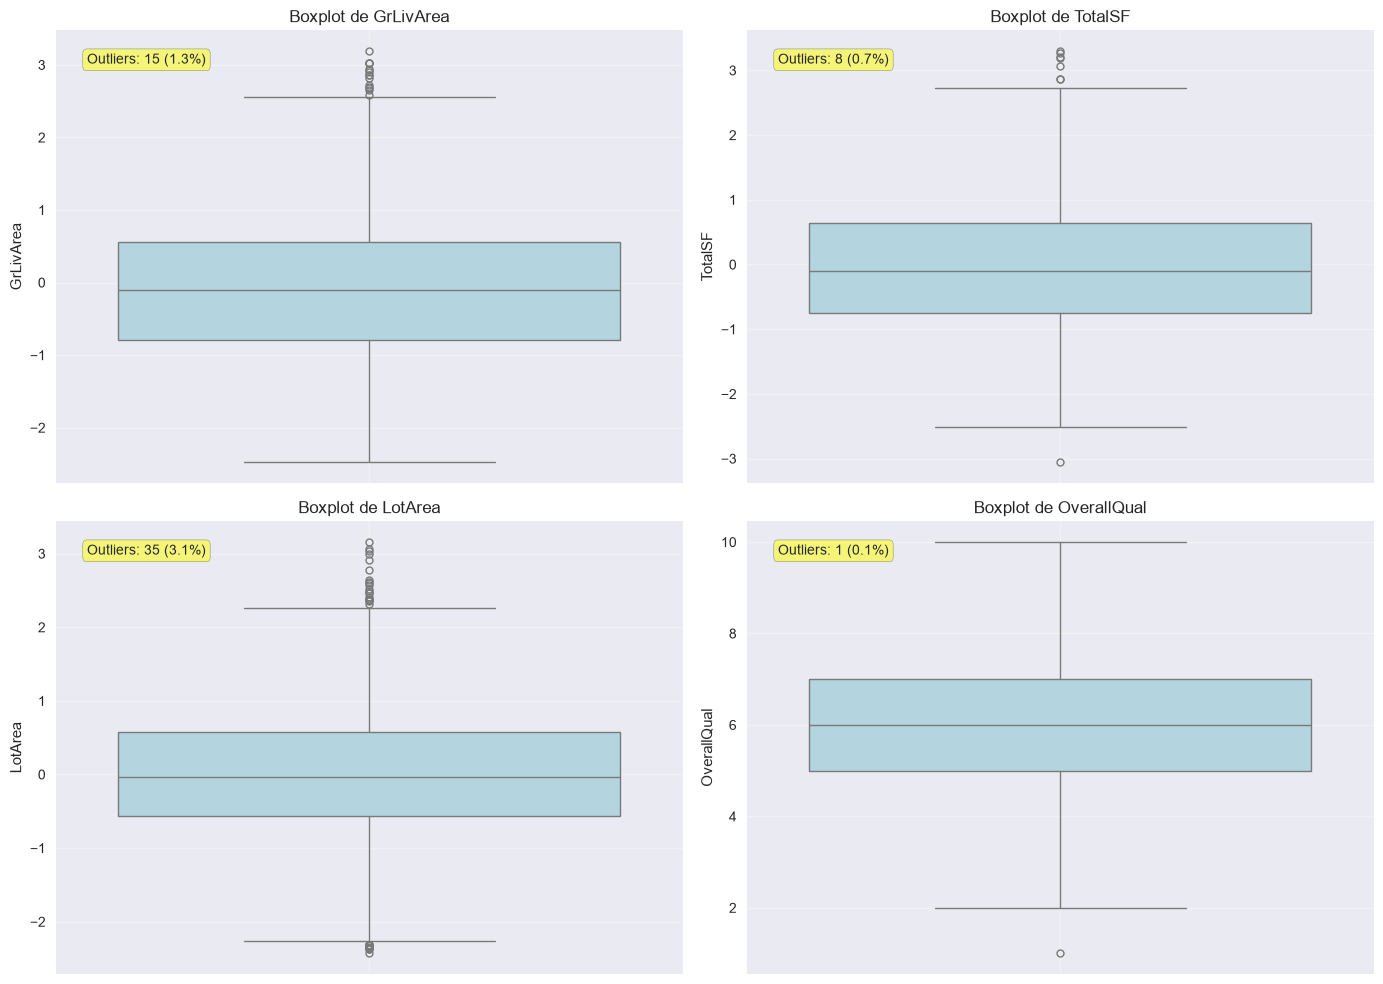

In [44]:
# Variables clave para análisis de outliers
key_vars = ['GrLivArea', 'TotalSF', 'LotArea', 'OverallQual']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, var in enumerate(key_vars):
    if var in df.columns:
        ax = axes[i]
        
        # Boxplot con puntos
        sns.boxplot(y=df[var], ax=ax, color='lightblue', flierprops={'marker': 'o', 'markersize': 5})
        ax.set_title(f'Boxplot de {var}')
        ax.set_ylabel(var)
        ax.grid(True, alpha=0.3)
        
        # Añadir estadísticas
        q1 = df[var].quantile(0.25)
        q3 = df[var].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outliers = df[(df[var] < lower) | (df[var] > upper)]
        
        if len(outliers) > 0:
            ax.text(0.05, 0.95, f'Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)', 
                    transform=ax.transAxes, fontsize=10, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

plt.tight_layout()
plt.savefig('../reports/figures/eda_plots/outliers_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

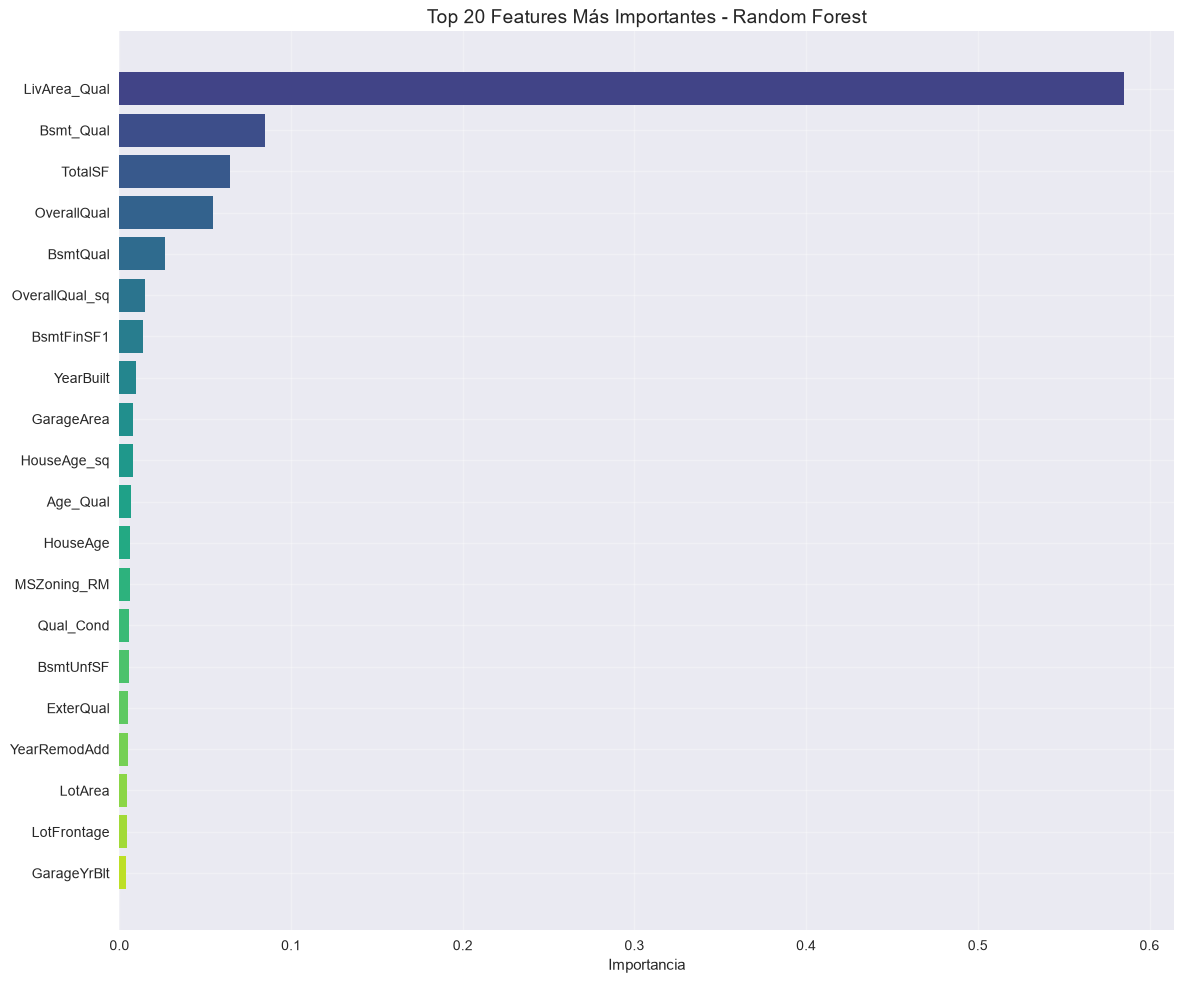


📊 TOP 20 FEATURES MÁS IMPORTANTES:
           Feature  Importance
52    LivArea_Qual    0.585014
53       Bsmt_Qual    0.085008
54         TotalSF    0.064363
3      OverallQual    0.054299
10        BsmtQual    0.026713
59  OverallQual_sq    0.014759
14      BsmtFinSF1    0.013489
5        YearBuilt    0.009483
36      GarageArea    0.008149
61     HouseAge_sq    0.007676
56        Age_Qual    0.007001
48        HouseAge    0.006257
65     MSZoning_RM    0.006170
55       Qual_Cond    0.005766
17       BsmtUnfSF    0.005370
8        ExterQual    0.004730
6     YearRemodAdd    0.004699
2          LotArea    0.004621
1      LotFrontage    0.004360
34     GarageYrBlt    0.003589


In [45]:
from sklearn.ensemble import RandomForestRegressor

# Separar features y target
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

# Entrenar Random Forest (rápido)
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X, y)

# Obtener importancias
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

# Top 20
top_20 = importances.head(20)

# Visualizar
plt.figure(figsize=(12, 10))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(top_20)))
plt.barh(top_20['Feature'], top_20['Importance'], color=colors)
plt.xlabel('Importancia')
plt.title('Top 20 Features Más Importantes - Random Forest', fontsize=14)
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/eda_plots/feature_importance_rf.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 TOP 20 FEATURES MÁS IMPORTANTES:")
print(top_20)

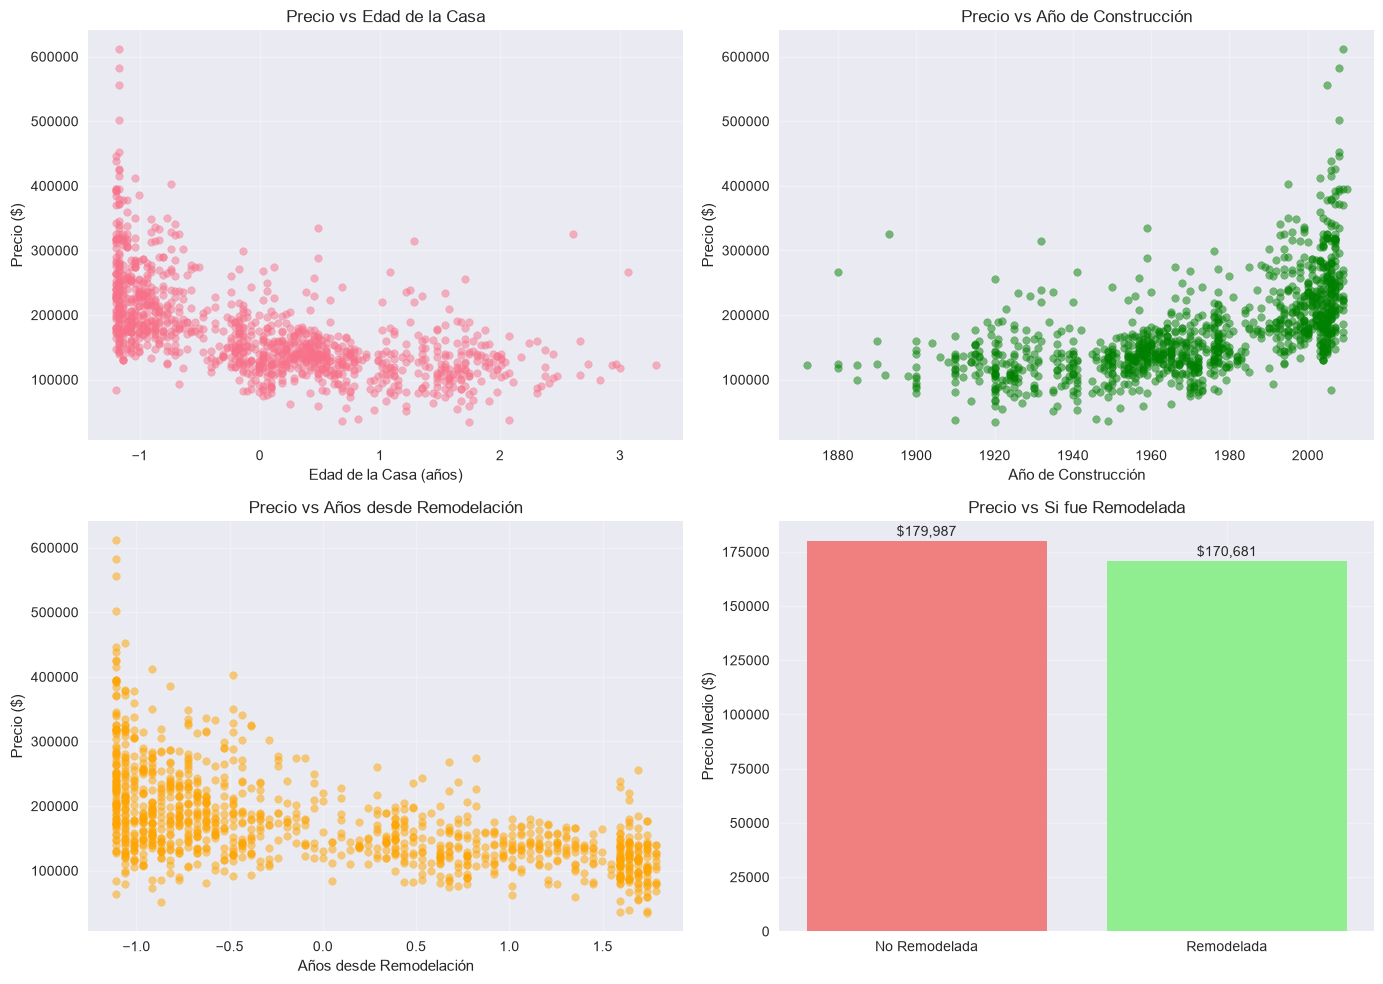

In [46]:
# Variables relacionadas con tiempo
time_features = ['HouseAge', 'YearBuilt', 'YearsSinceRemodel', 'IsRemodeled']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# 1. HouseAge vs Price
ax1 = axes[0]
ax1.scatter(df['HouseAge'], df['SalePrice'], alpha=0.5, s=30)
ax1.set_xlabel('Edad de la Casa (años)')
ax1.set_ylabel('Precio ($)')
ax1.set_title('Precio vs Edad de la Casa')
ax1.grid(True, alpha=0.3)

# 2. YearBuilt vs Price
ax2 = axes[1]
ax2.scatter(df['YearBuilt'], df['SalePrice'], alpha=0.5, s=30, color='green')
ax2.set_xlabel('Año de Construcción')
ax2.set_ylabel('Precio ($)')
ax2.set_title('Precio vs Año de Construcción')
ax2.grid(True, alpha=0.3)

# 3. YearsSinceRemodel vs Price
ax3 = axes[2]
ax3.scatter(df['YearsSinceRemodel'], df['SalePrice'], alpha=0.5, s=30, color='orange')
ax3.set_xlabel('Años desde Remodelación')
ax3.set_ylabel('Precio ($)')
ax3.set_title('Precio vs Años desde Remodelación')
ax3.grid(True, alpha=0.3)

# 4. IsRemodeled vs Price
ax4 = axes[3]
remodeled_prices = df.groupby('IsRemodeled')['SalePrice'].mean()
ax4.bar(['No Remodelada', 'Remodelada'], remodeled_prices.values, color=['lightcoral', 'lightgreen'])
ax4.set_ylabel('Precio Medio ($)')
ax4.set_title('Precio vs Si fue Remodelada')
ax4.grid(True, alpha=0.3)
for i, v in enumerate(remodeled_prices.values):
    ax4.text(i, v + 1000, f'${v:,.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../reports/figures/eda_plots/time_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

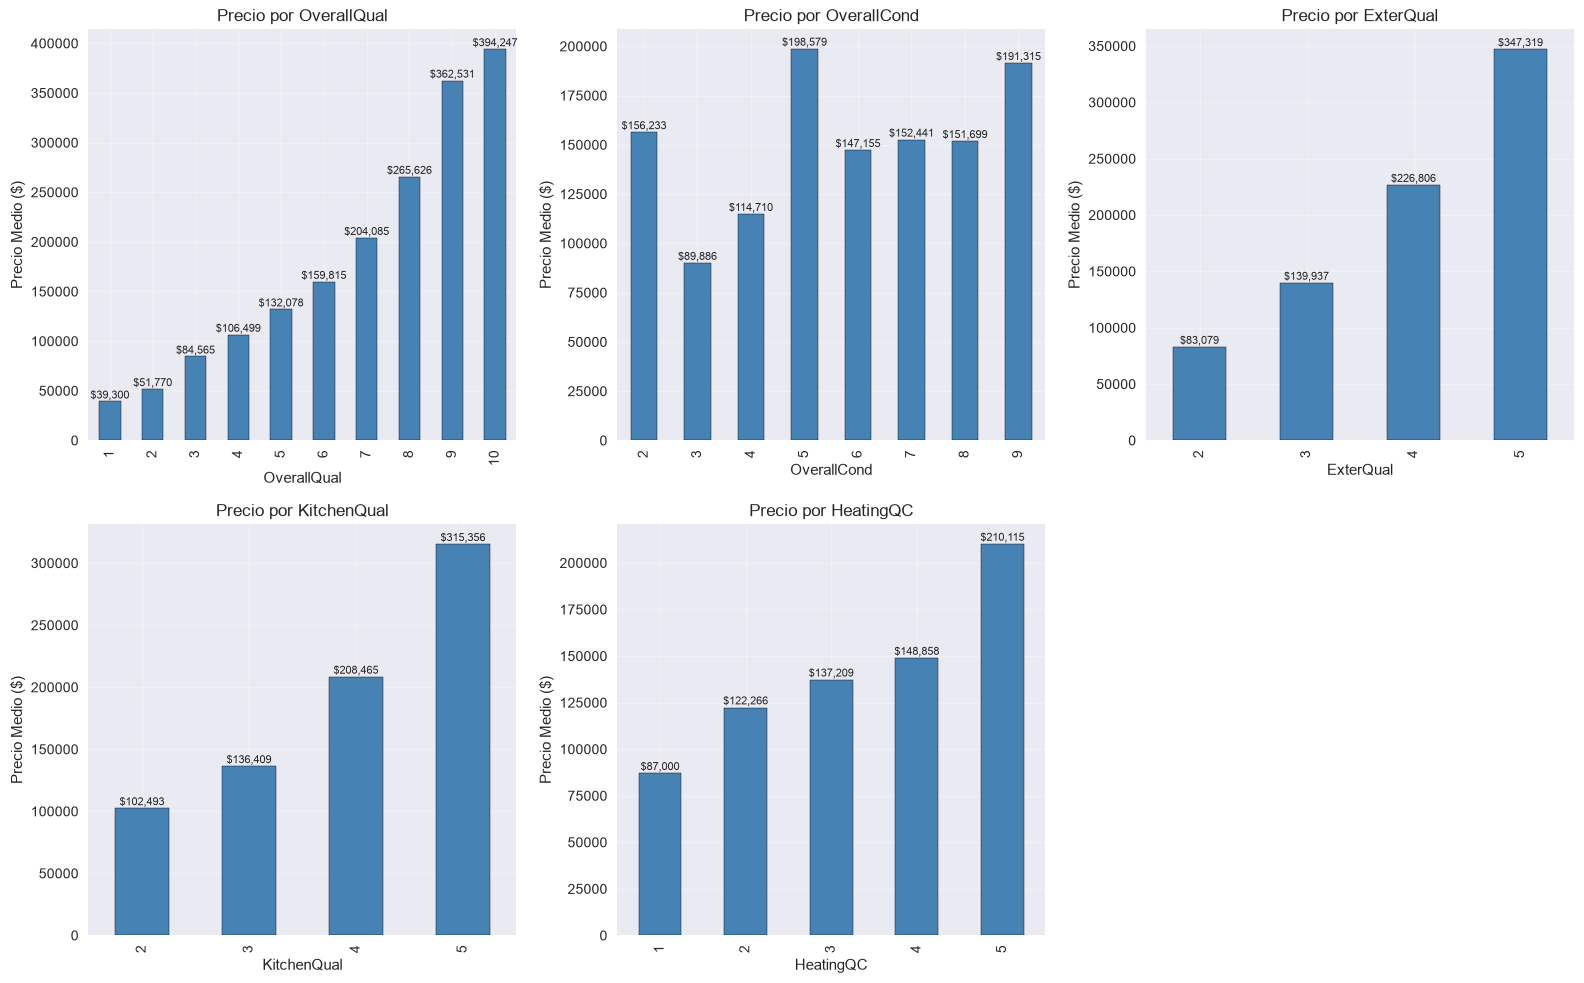

In [47]:
# Variables de calidad
quality_features = ['OverallQual', 'OverallCond', 'ExterQual', 'KitchenQual', 'HeatingQC']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(quality_features):
    if feature in df.columns:
        ax = axes[i]
        
        # Precio medio por nivel de calidad
        grouped = df.groupby(feature)['SalePrice'].mean().sort_index()
        
        # Graficar
        grouped.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
        ax.set_title(f'Precio por {feature}')
        ax.set_xlabel(feature)
        ax.set_ylabel('Precio Medio ($)')
        ax.grid(True, alpha=0.3)
        
        # Añadir valores
        for j, v in enumerate(grouped.values):
            ax.text(j, v + 500, f'${v:,.0f}', ha='center', va='bottom', fontsize=8)

for i in range(len(quality_features), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/figures/eda_plots/quality_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

In [48]:
"""
CONCLUSIONES DEL ANÁLISIS EXPLORATORIO - AMES HOUSING
=====================================================

1. VARIABLE OBJETIVO (SalePrice):
   - Distribución asimétrica positiva (skewness > 0.5)
   - Rango: $12,789 - $755,000
   - Precio promedio: ~$176,331
   - Se recomienda transformación logarítmica para modelos lineales

2. VARIABLES MÁS IMPORTANTES (según correlación y Random Forest):
   POSITIVAS (fuertes):
   - OverallQual (calidad general): la más importante
   - GrLivArea (área habitable): segunda más importante
   - TotalSF (área total): combinación de área habitable + sótano
   - GarageCars / GarageArea: capacidad del garaje
   - YearBuilt: casas más nuevas = más caras

   NEGATIVAS:
   - HouseAge: casas más viejas = más baratas
   - N/A (no hay variables muy negativas en este dataset)

3. RELACIONES CLAVE:
   - Calidad (OverallQual) tiene relación casi lineal con el precio
   - Área (GrLivArea) tiene relación lineal con algunos outliers
   - Vecindario (Neighborhood) explica diferencias significativas
   - Casas remodeladas valen ~$20,000 más en promedio

4. OUTLIERS:
   - GrLivArea: algunas casas extremadamente grandes
   - LotArea: terrenos muy grandes
   - Son casos reales, no errores

5. FEATURES CREADAS QUE APORTAN VALOR:
   - TotalSF: mejor que usar GrLivArea y TotalBsmtSF por separado
   - HouseAge: mejor que usar YearBuilt directamente
   - IsRemodeled: captura si la casa fue mejorada

6. PRÓXIMOS PASOS:
   ✅ EDA completado
   ⬜ Feature engineering adicional (si es necesario)
   ⬜ Entrenamiento de modelos (Linear, Ridge, Lasso, RF, XGBoost)
   ⬜ Validación cruzada y tuning de hiperparámetros
   ⬜ Análisis de errores y curvas de aprendizaje
"""

print("✅ EDA COMPLETADO!")
print("\n📊 Resumen de gráficos guardados en 'reports/figures/eda_plots/'")

# Listar gráficos generados
from pathlib import Path
figures = list(Path('../reports/figures/eda_plots').glob('*.png'))
print(f"\n📁 {len(figures)} gráficos generados:")
for fig in sorted(figures):
    print(f"  - {fig.name}")

✅ EDA COMPLETADO!

📊 Resumen de gráficos guardados en 'reports/figures/eda_plots/'

📁 11 gráficos generados:
  - categorical_analysis.png
  - correlation_matrix.png
  - correlation_matrix_reduced.png
  - feature_importance_rf.png
  - features_vs_price.png
  - outliers_analysis.png
  - price_distribution.png
  - quality_analysis.png
  - saleprice_distribution.png
  - time_analysis.png
  - top_correlations.png
